In [1]:
import mat73
import numpy as np
from matplotlib import pyplot as plt
data_dict = mat73.loadmat("assets/in/data_figure6/Data_SMA.mat")

In [2]:
from qnmsc.track_qnms import track_qnms
from qnmsc.plot_trajectories import load_data, select_modes
from qnmsc.plot_splitting import plot_splitting
from qnmsc.mpl_config import um, inv_um, mm, config
%autoreload

In [3]:
config()

In [4]:
from scipy.constants import h, c as c0,e
k0_to_eV = 1e6*h*c0/e/(2*np.pi)

In [5]:
kn = data_dict['kn']

In [6]:
thickness_surmof = np.array([T[0][1] for T in kn['T']])
Nt = len(thickness_surmof)

In [7]:
poles = np.sort(kn['poles'][0][0])[-3:] * k0_to_eV

In [8]:
poles

array([1.70658014-0.01095198j, 1.81135347-0.01239838j,
       1.85469782-0.01281178j])

In [9]:
q_rse   = np.zeros((Nt, 4), dtype=complex)
gcoeff  = np.zeros((Nt, 3), dtype=complex)
kcshift = np.zeros((Nt, 1), dtype=complex)
kc      = np.zeros((Nt, 1), dtype=complex)

for i in range(Nt):
    q_rse[i,:] = np.sort(kn['knNew'][i][0])

    gcoeff[i,:] = kn['coupl_coeffs'][i][0][::-1]
    kcshift[i] = kn['knShift'][i][0]
    kc[i] = kn['knVal'][i][0][0]

q_rse   *= k0_to_eV
gcoeff  *= k0_to_eV
kcshift *= k0_to_eV
kc      *= k0_to_eV


In [10]:
X_rse = thickness_surmof*1e6

QNMs at rabi: [1.4565377 -0.0555689j  1.7987035 -0.01398423j 1.84747228-0.01379213j
 2.09787132-0.09162223j]


/mnt/data/jd/code/misc/agsurmof/qnmsc/inverse_eigenproblem.py:50: RuntimeWarning: invalid value encountered in divide
  fac = -1/(oms-evs)
/mnt/data/jd/code/misc/agsurmof/qnmsc/plot_splitting.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=5, labelcolor=c_font, loc=legend_loc)


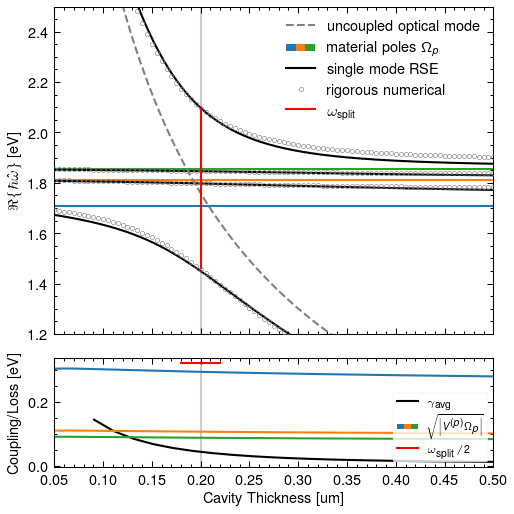

In [11]:
from qnmsc.mpl_config import MulticolorPatch, MulticolorPatchHandler

domain = [0.7-0.7j, 5.0+0.05j]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(90*mm, 90*mm), height_ratios=[3,1])

fig, axs, om_os, Cs, param = plot_splitting(
    1,3,1,1,domain, inv_d=False, return_fit=True, plot_dots=False, n_interp=60, axs=axs, 
    plot_cavity_mode=False, c_higher=[0,0,0,0], plot_extracted_coupling=False, scatter_numerical=True, fill_legend=False)

plt.sca(axs[1])
plt.plot(X_rse, np.abs(np.sqrt(gcoeff*poles)))

plt.plot([],[], color="r", label=r"$\omega_\mathrm{split}/2$")
#plt.gca().get_legend().remove()
plt.ylabel(r"Coupling/Loss [eV]")

# ------ get the legend-entries that are already attached to the axis
h, l = axs[1].get_legend_handles_labels()

# ------ append the multicolor legend patches
h.insert(1, MulticolorPatch(['C0', 'C1', 'C2']))
l.insert(1, r"$\sqrt{\left|V^{(p)}\Omega_p\right|}$")

plt.legend(h, l, fontsize=5, loc="lower right", frameon=True, handler_map={MulticolorPatch: MulticolorPatchHandler()})

#plt.xlim(1.5, 15)
plt.xlim(0.05, 0.5)
plt.ylim()

plt.sca(axs[0])
plt.plot(X_rse, q_rse.real, color="k")
#plt.plot(X_rse, kcshift.real)
plt.plot(X_rse, kc.real, "gray", ls="--")


plt.plot([], [], color="gray", ls="--", label="uncoupled optical mode")
plt.plot([], [], color="k", label="single mode RSE")
plt.plot([], [], label="rigorous numerical", mec="gray", marker="o", mfc="none", ls="none", ms=2)
plt.plot([], [], color="r", label="$\omega_\mathrm{split}$")

# ------ get the legend-entries that are already attached to the axis
h, l = axs[0].get_legend_handles_labels()

# ------ append the multicolor legend patches
h.insert(1, MulticolorPatch(['C0', 'C1', 'C2']))
l.insert(1, r"material poles $\Omega_p$")

plt.legend(h, l, handler_map={MulticolorPatch: MulticolorPatchHandler()})
plt.savefig("out/SMA_RSE.pdf", bbox_inches="tight")